In [1]:
import fig02
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

from drift_diffusion.model import DriftDiffusionModel
from drift_diffusion.sim import sample_from_ssm

# notebook defaults
plt.rcParams.update({"font.size": 14, "font.family": "Helvetica", "savefig.transparent": True})

In [2]:
# !! specify simulation settings !!
SETTING = "iid"  # "constant", "coherence", or "iid"
REFIT = False  # True to refit simulations, False to load precomputed results
kwargs = dict(n_samples=1000, n_repeats=900, random_state=0)

# DDM parameters, from Matzke 2009, Table 3 (Mean)
params = dict(a=0.63, t0=0.435, v=2.23, z=0.008)
params_s = dict(t0=0.183, v=1.33, z=0.37)


def setup_constant():
    """setup constant DDM parameters"""
    param_names = ["a", "t0", "v", "z"]
    cov_names = [f"{i},{j}" for i in param_names for j in param_names]
    pseudotrue_params = params
    X = pd.DataFrame({"intercept": np.ones(kwargs["n_samples"])})
    ys = sample_from_ssm(**params, **kwargs)
    ddm = DriftDiffusionModel(cov_estimator="all")
    return X, ys, ddm, param_names, cov_names, pseudotrue_params


def setup_coherence():
    """setup v as linear function of coherence"""
    param_names = ["a", "t0", "beta_v", "z"]
    cov_names = [f"{i},{j}" for i in param_names for j in param_names]
    rng = np.random.default_rng(kwargs["random_state"])
    beta_v = 1
    coh = rng.uniform(
        params["v"] - params_s["v"] * np.sqrt(3), params["v"] + params_s["v"] * np.sqrt(3), kwargs["n_samples"]
    )
    v_coh = beta_v * coh
    X = pd.DataFrame({"intercept": np.ones(kwargs["n_samples"]), "coherence": coh})
    ys = sample_from_ssm(a=params["a"], t0=params["t0"], v=v_coh, z=params["z"], **kwargs)
    ddm = DriftDiffusionModel(v="-1+coherence", cov_estimator="all")
    pseudotrue_params = {"a": params["a"], "t0": params["t0"], "beta_v": 1, "z": params["z"]}
    return X, ys, ddm, param_names, cov_names, pseudotrue_params


def setup_iid():
    """setup t0, v, z to vary iid"""
    param_names = ["a", "t0", "v", "z"]
    cov_names = [f"{i},{j}" for i in param_names for j in param_names]
    n = 10_000
    X_pt = pd.DataFrame({"intercept": np.ones(n)})
    t0_iid, v_iid, z_iid = fig02.iid_params(n, params, params_s)
    y_pt = sample_from_ssm(
        a=params["a"], t0=t0_iid, v=v_iid, z=z_iid, n_samples=n, n_repeats=1, random_state=kwargs["random_state"]
    )
    ddm = DriftDiffusionModel()
    ddm.fit(X_pt, y_pt)
    pseudotrue_params = dict(zip(param_names, ddm.params_))
    X = pd.DataFrame({"intercept": np.ones(kwargs["n_samples"])})
    t0_iid, v_iid, z_iid = fig02.iid_params(kwargs["n_samples"], params, params_s)
    ys = sample_from_ssm(a=params["a"], t0=t0_iid, v=v_iid, z=z_iid, **kwargs)
    ddm = DriftDiffusionModel(cov_estimator="all")
    return X, ys, ddm, param_names, cov_names, pseudotrue_params


if SETTING == "constant":
    X, ys, ddm, param_names, cov_names, pseudotrue_params = setup_constant()
elif SETTING == "coherence":
    X, ys, ddm, param_names, cov_names, pseudotrue_params = setup_coherence()
elif SETTING == "iid":
    X, ys, ddm, param_names, cov_names, pseudotrue_params = setup_iid()
else:
    raise ValueError("choose 'constant', 'coherence', or 'iid'")

In [3]:
# fit or load simulation results
@delayed
def run_simulation(rep):
    ddm.fit(X, ys[:, rep])
    covs_ = [
        {"estimator": k, **{cov_names[i]: val for i, val in enumerate(fig02.cov_to_corr(v).flatten())}}
        for k, v in ddm.covariance_.items()
    ]
    return ddm.params_, covs_


if REFIT:
    with Parallel(n_jobs=-4) as parallel:
        results = parallel(run_simulation(rep) for rep in tqdm(range(kwargs["n_repeats"])))
        params_, covs_ = zip(*results)
        params_df = pd.DataFrame(params_, columns=param_names)
        covs_df = pd.DataFrame([row for c in covs_ for row in c])
else:
    params_df = pd.read_csv(f"results/sim-{SETTING}-params.csv")
    covs_df = pd.read_csv(f"results/sim-{SETTING}-covs.csv")

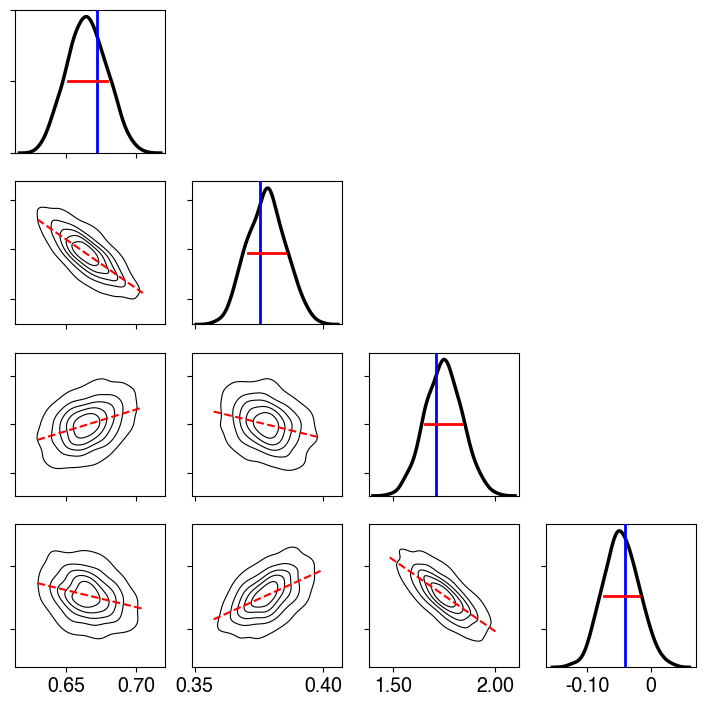

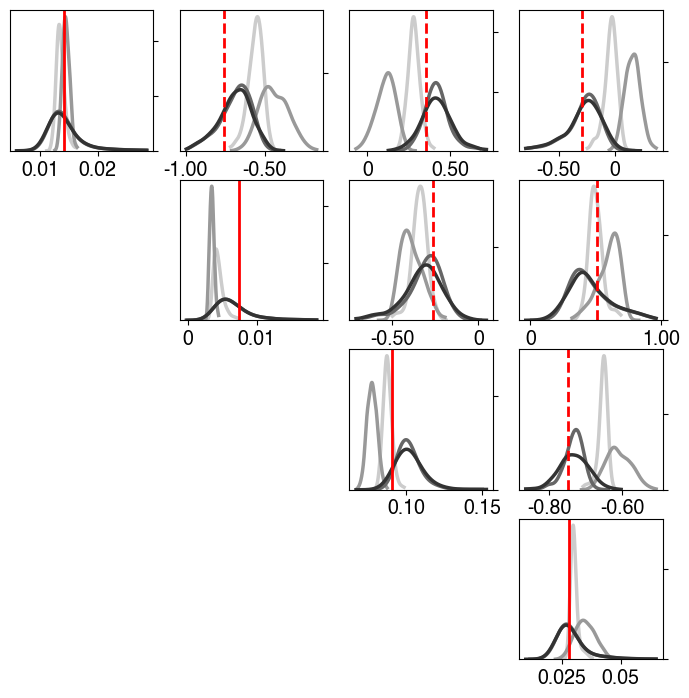

In [ ]:
# plot results
fig = fig02.plot_parameter_distributions(params_df, pseudotrue_params)
fig = fig02.plot_covariance_distributions(covs_df, params_df)